In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
mean_1 = np.array([-1.0,2.0])
mean_2 =np.array([2.0,2.0])
shared_covariance = np.array([[2 ,0],
                             [0,3]])
prior_1 = prior_2 = 0.5

In [18]:
def gaussian_log_score(X, mean, covariance, prior):
    """Bayes score: log p(x | class) + log P(class)."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    mean = np.asarray(mean, dtype=float)
    covariance = np.asarray(covariance, dtype=float)

    if prior <= 0:
        raise ValueError("prior must be positive")

    d = mean.size
    sign, log_det = np.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("covariance must be positive definite")

    difference = X - mean
    solved = np.linalg.solve(covariance, difference.T).T
    mahalanobis_sq = np.sum(difference * solved, axis=1)

    return (
        -0.5 * d * np.log(2 * np.pi)
        -0.5 * log_det
        -0.5 * mahalanobis_sq
        + np.log(prior)
    )

In [20]:
test_point = np.array([0.3,0.9])
score_1  = gaussian_log_score(test_point,mean_1,shared_covariance,prior_1)[0]
score_2 = gaussian_log_score(test_point,mean_2,shared_covariance,prior_2)[0]
print("\nBayes classification for one point")
print("Test point:", test_point)
print("Class 1 log-score:", score_1)
print("Class 2 log-score:", score_2)
print("Predicted class:", 1 if score_1 > score_2 else 2)


Bayes classification for one point
Test point: [0.3 0.9]
Class 1 log-score: -4.0510706482499845
Class 2 log-score: -4.351070648249984
Predicted class: 1


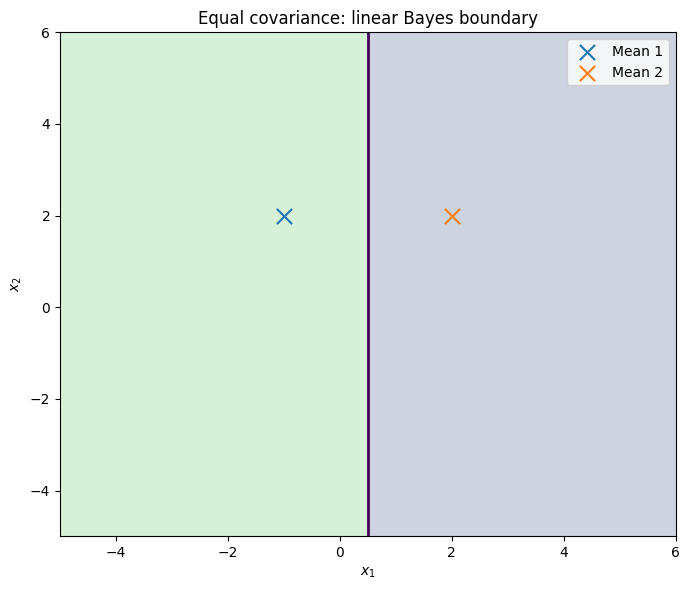

In [26]:
x1 = np.linspace(-5, 6, 300)
x2 = np.linspace(-5, 6, 300)
xx, yy = np.meshgrid(x1, x2)
grid = np.column_stack([xx.ravel(), yy.ravel()])
g1 = gaussian_log_score(grid, mean_1, shared_covariance, prior_1)
g2 = gaussian_log_score(grid, mean_2, shared_covariance, prior_2)
difference = (g1 - g2).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, difference, levels=[-1e9, 0, 1e9], alpha=0.25)
plt.contour(xx, yy, difference, levels=[0], linewidths=2)
plt.scatter(mean_1[0], mean_1[1], marker="x", s=120, label="Mean 1")
plt.scatter(mean_2[0], mean_2[1], marker="x", s=120, label="Mean 2")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Equal covariance: linear Bayes boundary")
plt.legend()
plt.tight_layout()
plt.show()